In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv('../data/processed_data.csv')

# On s'assure d'avoir les colonnes nécessaires
# total_input, fee, num_outputs, fee_rate

In [2]:
# --- STRATÉGIE 1 : CONGESTION (Priority Bumping) ---
# L'acteur paie des frais extrêmes pour passer en priorité.
# Rationnel pour un arbitrageur, suspect pour un blanchisseur pressé.
def detect_congestion_strategy(row):
    # Si le fee_rate est 5x supérieur à la moyenne du dataset
    if row['fee_rate'] > df['fee_rate'].median() * 5:
        return 1
    return 0

# --- STRATÉGIE 2 : DILEMME DU MIXEUR (Fragmentation) ---
# L'acteur accepte de payer plus de frais globaux pour diviser ses fonds.
# On regarde le ratio entre le nombre de sorties et le montant total.
def detect_mixer_strategy(row):
    if row['num_outputs'] > 10 and row['output_dominance'] < 0.5:
        return 1
    return 0

# --- STRATÉGIE 3 : SYBIL / SPAM (Micro-Transactions) ---
# Création de volume artificiel avec de très petits montants.
def detect_sybil_strategy(row):
    if row['total_input'] < df['total_input'].quantile(0.1) and row['tx_density'] > 0.8:
        return 1
    return 0

# Application des fonctions
df['strat_congestion'] = df.apply(detect_congestion_strategy, axis=1)
df['strat_mixer'] = df.apply(detect_mixer_strategy, axis=1)
df['strat_sybil'] = df.apply(detect_sybil_strategy, axis=1)

# Score de Risque Stratégique Global
df['strategic_risk_score'] = df['strat_congestion'] + df['strat_mixer'] + df['strat_sybil']

C:\Users\user\AppData\Local\Temp\ipykernel_1668\3094136057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strat_counts.index, y=strat_counts.values, palette='viridis')


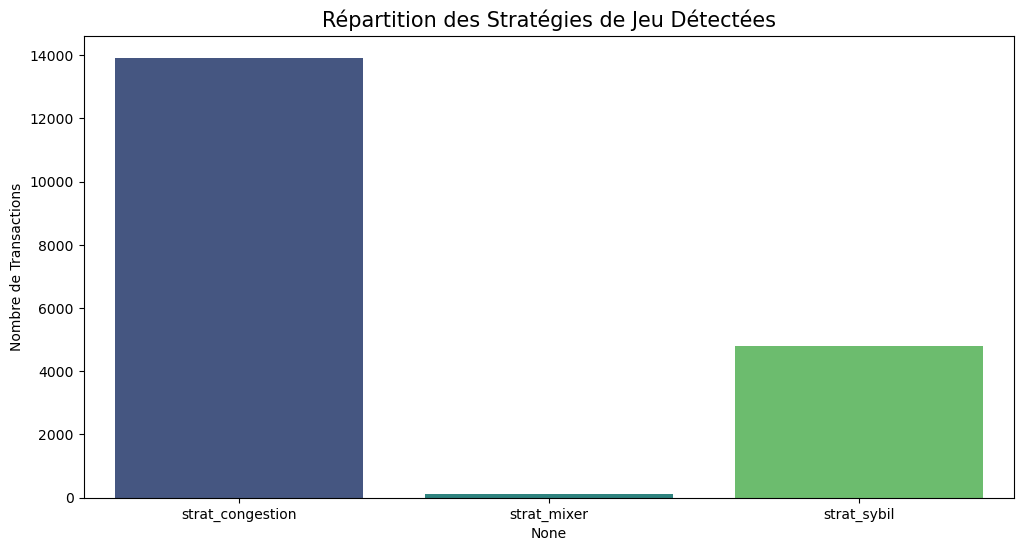

Transactions suspectes détectées par Théorie des Jeux : 18611


In [3]:
plt.figure(figsize=(12, 6))
strat_counts = df[['strat_congestion', 'strat_mixer', 'strat_sybil']].sum()

sns.barplot(x=strat_counts.index, y=strat_counts.values, palette='viridis')
plt.title('Répartition des Stratégies de Jeu Détectées', fontsize=15)
plt.ylabel('Nombre de Transactions')
plt.show()

print(f"Transactions suspectes détectées par Théorie des Jeux : {len(df[df['strategic_risk_score'] > 0])}")

⚔️ Stratégie 1 : La Congestion (L'Urgence de l'Attaquant)
Cette stratégie repose sur le sacrifice du profit au profit de la vitesse. Dans le protocole Bitcoin, plus les frais (fee_rate) sont élevés, plus la transaction est traitée rapidement par les mineurs. Un utilisateur normal optimise ses coûts en attendant une baisse des frais. À l'inverse, un fraudeur utilise le "Priority Bumping" : il paie un prix extrême (5x la moyenne) pour s'assurer que ses fonds soient déplacés et "blanchis" avant que les systèmes de surveillance ou les autorités ne puissent geler son adresse. C'est une course contre la montre stratégique.


🛡️ Stratégie 2 : Le Mixage (Le Coût de l'Anonymat)
Le dilemme du mixeur est un arbitrage entre clarté et confidentialité. Ici, l'acteur choisit de fragmenter un montant important en une multitude de petites sorties (num_outputs > 10) de valeurs quasi identiques (low dominance). Techniquement, multiplier les sorties augmente considérablement la taille de la transaction et donc les frais à payer. Économiquement, ce comportement est irrationnel. Stratégiquement, c'est une méthode calculée pour "noyer" la trace des fonds dans un bruit numérique, rendant le traçage sur le graphe extrêmement complexe pour les analystes.

📡 Stratégie 3 : L'Attaque Sybil (La Simulation de Volume)
La stratégie Sybil consiste à inonder le réseau de micro-transactions pour manipuler la perception de l'activité. L'attaquant crée des centaines d'identités fictives (adresses) qui s'envoient des montants minuscules, souvent proches du minimum autorisé. L'objectif n'est pas le transfert de valeur, mais la création d'un "écran de fumée". En saturant le dataset de transactions à haute densité mais à faible utilité économique, le fraudeur espère que sa véritable transaction illégale passera inaperçue, perdue dans une masse de données sans importance.

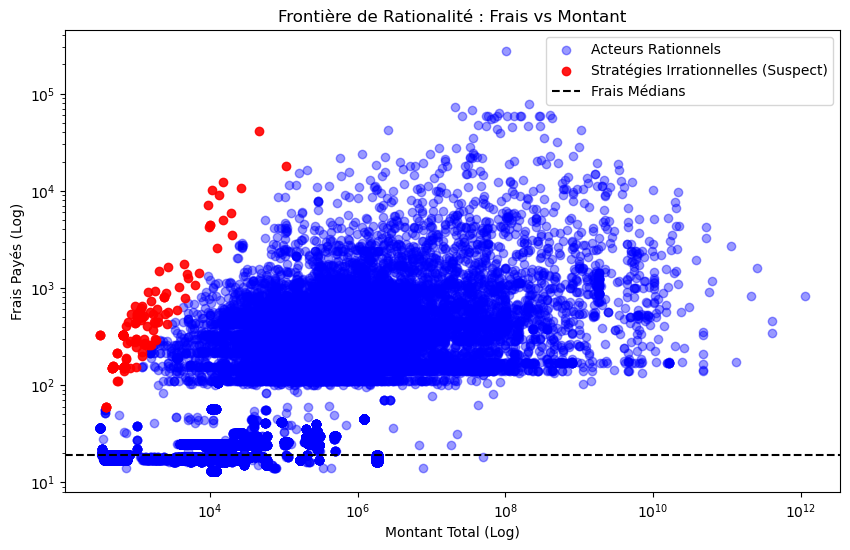

In [5]:
plt.figure(figsize=(10, 6))

# On définit la zone d'irrationalité (Frais > 15% du montant)
df['irrational'] = (df['fee'] / df['total_input']) > 0.15

plt.scatter(df[~df['irrational']]['total_input'], df[~df['irrational']]['fee'], 
            alpha=0.4, c='blue', label='Acteurs Rationnels')
plt.scatter(df[df['irrational']]['total_input'], df[df['irrational']]['fee'], 
            alpha=0.9, c='red', label='Stratégies Irrationnelles (Suspect)')

plt.xscale('log')
plt.yscale('log')
plt.axhline(y=df['fee'].median(), color='black', linestyle='--', label='Frais Médians')
plt.title('Frontière de Rationalité : Frais vs Montant')
plt.xlabel('Montant Total (Log)')
plt.ylabel('Frais Payés (Log)')
plt.legend()
plt.show()